# SOLUCIÓN Minería de Datos — Árboles de Decisión con Dataset Titanic
*   David Santiago Aldana Gonzalez - 20222020158
*   Sara Nicolle Martinez Moreno - 20231020116
*   Juan Diego Grajales Castillo - 20221020128
*   Julian David Celis Giraldo - 20222020041

##Grupo 4

**Asignatura:** Minería de Datos  
**Tema:** Clasificación supervisada con árboles de decisión  
**Nivel:** Ingeniería de Sistemas  

---

## Propósito de la clase

En esta clase estudiaremos **árboles de decisión** usando un dataset en línea estable y ampliamente usado en ciencia de datos: **Titanic**.

El problema consiste en predecir si un pasajero sobrevivió o no al naufragio a partir de variables como:

- clase del pasajero,
- sexo,
- edad,
- tarifa pagada,
- número de familiares a bordo.

Este dataset es ideal para clase porque permite explicar:

1. Carga de datos desde internet.
2. Comprensión del problema.
3. Limpieza básica de datos.
4. Conversión de variables categóricas.
5. Separación train/test.
6. Entrenamiento de árboles de decisión.
7. Evaluación con métricas.
8. Interpretación de reglas.
9. Overfitting por profundidad.
10. Taller aplicado al final.

---

## Pregunta de minería de datos

> ¿Podemos predecir si un pasajero sobrevivió al Titanic usando sus características registradas?

Formalmente:

\[
f(X) \rightarrow y
\]

Donde:

- \(X\): características del pasajero.
- \(y\): sobrevivió o no sobrevivió.
- \(f\): modelo de clasificación aprendido desde los datos.

# 1. Ubicación dentro del curso

Hasta este punto del curso ya se han trabajado:

- Conceptos generales de minería de datos.
- CRISP-DM.
- Preparación de datos.
- Train/Test.
- Métricas de clasificación.
- Regresión logística.

Ahora se introduce un modelo supervisado distinto: **árboles de decisión**.

---

## ¿Por qué árboles de decisión?

Porque combinan dos elementos muy importantes:

1. **Capacidad predictiva:** permiten clasificar nuevos registros.
2. **Interpretabilidad:** generan reglas fáciles de explicar.

Mientras otros modelos pueden verse como “cajas negras”, un árbol permite explicar decisiones mediante reglas:

```text
SI Sex = female
Y Pclass <= 2
ENTONCES mayor probabilidad de sobrevivir
```

Esto conecta directamente con minería de datos aplicada: no basta predecir, también hay que explicar.

# 2. Concepto de árbol de decisión

Un árbol de decisión es un modelo que clasifica observaciones haciendo preguntas sucesivas.

Cada pregunta divide los datos en subconjuntos más homogéneos.

---

## Estructura de un árbol

| Elemento | Significado |
|---|---|
| Nodo raíz | Primera pregunta del árbol |
| Nodo interno | Pregunta intermedia |
| Rama | Resultado de una pregunta |
| Hoja | Decisión final |
| Profundidad | Número de niveles del árbol |
| Regla | Camino desde la raíz hasta una hoja |

---

## Ejemplo intuitivo

```text
¿El pasajero era mujer?
├── Sí  → Mayor probabilidad de sobrevivir
└── No
    ├── ¿Era niño?
    │   ├── Sí → Probabilidad intermedia
    │   └── No → Menor probabilidad
```

El árbol aprende estas reglas desde los datos.

# 3. Dataset Titanic

Usaremos un CSV público alojado en GitHub:

```python
https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv
```

Este dataset contiene información de pasajeros del Titanic.

---

## Algunas variables importantes

| Variable | Significado |
|---|---|
| PassengerId | Identificador del pasajero |
| Survived | 0 = no sobrevivió, 1 = sobrevivió |
| Pclass | Clase del tiquete: 1, 2 o 3 |
| Name | Nombre |
| Sex | Sexo |
| Age | Edad |
| SibSp | Hermanos/cónyuges a bordo |
| Parch | Padres/hijos a bordo |
| Ticket | Número de tiquete |
| Fare | Tarifa pagada |
| Cabin | Cabina |
| Embarked | Puerto de embarque |

---

## Variable objetivo

La variable que queremos predecir es:

\[
Survived
\]

- 0: No sobrevivió.
- 1: Sobrevivió.

In [ ]:
# ============================================================
# 1. Importar librerías
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 120)

# 4. Carga del dataset desde internet

En proyectos reales los datos pueden venir de:

- archivos CSV,
- bases de datos,
- APIs,
- repositorios públicos,
- sistemas transaccionales.

Aquí usamos un CSV en línea.

Si el profesor quiere blindar la clase, puede descargar el CSV antes de la sesión y tenerlo como respaldo.

In [ ]:
# ============================================================
# 2. Cargar dataset Titanic desde URL estable
# ============================================================

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

print("Dataset cargado correctamente.")
print("Dimensiones:", df.shape)

df.head()

Dataset cargado correctamente.
Dimensiones: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 5. Comprensión inicial del dataset

Antes de modelar debemos responder:

1. ¿Cuántas filas y columnas tiene el dataset?

Posee 12 filas y 891 registros

2. ¿Qué tipos de variables hay?

| Variable     | Tipo (naturaleza) | Subtipo              | Escala   | Comentario                                      |
|--------------|------------------|----------------------|----------|------------------------------------------------|
| PassengerId  | Cuantitativo     | Discreto             | Razón    | Identificador numérico (sin valor analítico)   |
| Survived     | Cualitativo      | Nominal (binario)    | Nominal  | 0 = no, 1 = sí                                |
| Pclass       | Cualitativo      | Ordinal              | Ordinal  | Clases 1, 2, 3 con orden social               |
| Name         | Cualitativo      | Nominal              | Nominal  | Texto identificador                           |
| Sex          | Cualitativo      | Nominal              | Nominal  | male / female                                 |
| Age          | Cuantitativo     | Continuo             | Razón    | Edad en años                                  |
| SibSp        | Cuantitativo     | Discreto             | Razón    | Número de hermanos/esposos                    |
| Parch        | Cuantitativo     | Discreto             | Razón    | Número de padres/hijos                        |
| Ticket       | Cualitativo      | Nominal              | Nominal  | Código de ticket                              |
| Fare         | Cuantitativo     | Continuo             | Razón    | Precio del pasaje                             |
| Cabin        | Cualitativo      | Nominal              | Nominal  | Código de cabina (con valores faltantes)      |
| Embarked     | Cualitativo      | Nominal              | Nominal  | Puerto de embarque (C, Q, S)                  |

3. ¿Cuál es la variable objetivo?

   Survived, utilizada para predecir si sobrevivió o no al naufragio

4. ¿Hay valores faltantes?
5.
   Si, Age -> 177 valores faltantes

   Si, Cabin -> 687 valores faltantes

   Si, embarked -> 2 valores faltantes

6. ¿Hay columnas que no aportan al modelo?
7.
   Si, PassengerId -> identificador

   Si, Name -> Identificador no aporta a predicción

   Si, ticket -> No es relevante para nuestro análisis

   Si, Cabin -> No es útil para el análisis

8. ¿Existen variables categóricas que deben codificarse?

   Si, Sex, tiene valores como male/female y que requieren pasar a ser cero y uno

   Si, Embarked, C, Q, S,

Este paso corresponde a la fase de **comprensión de datos** del proceso CRISP-DM.

In [ ]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
# Resumen estadístico básico
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Dooley, Mr. Patrick",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


In [ ]:
# Valores faltantes por columna
faltantes = pd.DataFrame({
    "faltantes": df.isna().sum(),
    "porcentaje": (df.isna().mean() * 100).round(2)
}).sort_values("faltantes", ascending=False)

faltantes

,faltantes,porcentaje
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


## Interpretación de valores faltantes

En Titanic suelen aparecer valores faltantes en:

- `Age`: edad no registrada para algunos pasajeros.
- `Cabin`: mucha información faltante.
- `Embarked`: algunos pocos valores faltantes.

Para esta clase:

- Usaremos `Age`, imputando los faltantes con la mediana.
- No usaremos `Cabin`, porque tiene demasiados faltantes.
- Usaremos `Embarked`, imputando con la moda si es necesario.

# 6. Distribución de la variable objetivo

Revisaremos cuántos pasajeros sobrevivieron y cuántos no.

Esto es importante porque una clasificación con clases desbalanceadas puede hacer que el accuracy sea engañoso.

In [ ]:
conteo = df["Survived"].value_counts().sort_index()
porcentaje = df["Survived"].value_counts(normalize=True).sort_index() * 100

resumen_target = pd.DataFrame({
    "Survived": conteo.index,
    "descripcion": ["No sobrevivió", "Sobrevivió"],
    "conteo": conteo.values,
    "porcentaje": porcentaje.round(2).values
})

resumen_target

,Survived,descripcion,conteo,porcentaje
0,0,No sobrevivió,549,61.62
1,1,Sobrevivió,342,38.38


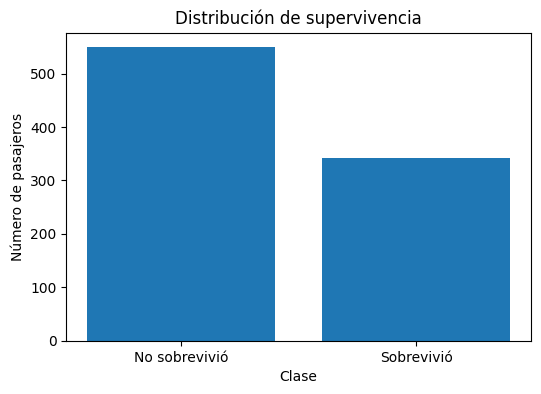

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(resumen_target["descripcion"], resumen_target["conteo"])
plt.title("Distribución de supervivencia")
plt.xlabel("Clase")
plt.ylabel("Número de pasajeros")
plt.show()

## Preguntas para clase

1. ¿Hay más sobrevivientes o no sobrevivientes?

   Existe mayor cantidad de no sobrevivientes que de sobrevivientes

2. ¿El dataset está muy desbalanceado?

    Esta levemente desbalanceado, casi un 65/35 aprox.
   
3. ¿Qué pasaría si un modelo predijera siempre “no sobrevivió”?

    Si, dijera siempre que no sobrevivió, no tendria sentido, sabemos que de 550 de 891 aprox. no sobrevivió, pero, el problema es que si predijera siempre que no sobrevivió, el modelo no aprende nada e ignora completamente la clase minoritaria (sobrevivientes)

4. ¿Accuracy sería suficiente?

No, dado que utilizamos un modelo de arboles de decisión, solo accuracy ya logra 62% y no distingue bien entre clases, requerimos metricas como:

* Precision
* Recall
* F1-score
* Matriz de confusión
  
Esta discusión conecta con matriz de confusión y métricas de clasificación.

# 7. Exploración visual sencilla

Antes de entrenar el árbol, observemos algunas relaciones:

- Supervivencia por sexo.
- Supervivencia por clase.
- Distribución de edad por supervivencia.
- Tarifa pagada por supervivencia.

Esto ayuda a entender qué patrones podría aprender el árbol.

In [ ]:
# Supervivencia por sexo
tabla_sex = pd.crosstab(df["Sex"], df["Survived"], normalize="index") * 100
tabla_sex.columns = ["No sobrevivió (%)", "Sobrevivió (%)"]
tabla_sex.round(2)

,No sobrevivió (%),Sobrevivió (%)
Sex,,
female,25.80,74.20
male,81.11,18.89


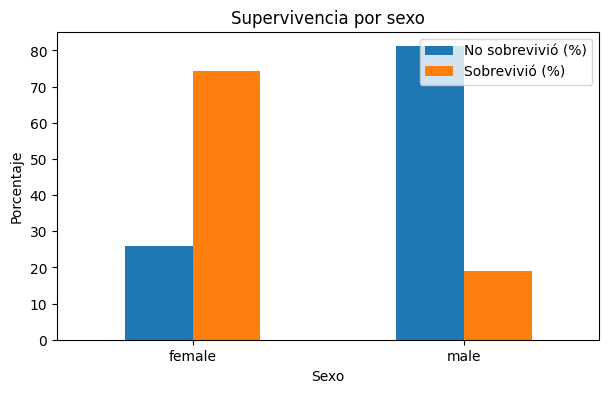

In [ ]:
tabla_sex.plot(kind="bar", figsize=(7,4))
plt.title("Supervivencia por sexo")
plt.xlabel("Sexo")
plt.ylabel("Porcentaje")
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Supervivencia por clase
tabla_clase = pd.crosstab(df["Pclass"], df["Survived"], normalize="index") * 100
tabla_clase.columns = ["No sobrevivió (%)", "Sobrevivió (%)"]
tabla_clase.round(2)

,No sobrevivió (%),Sobrevivió (%)
Pclass,,
1,37.04,62.96
2,52.72,47.28
3,75.76,24.24


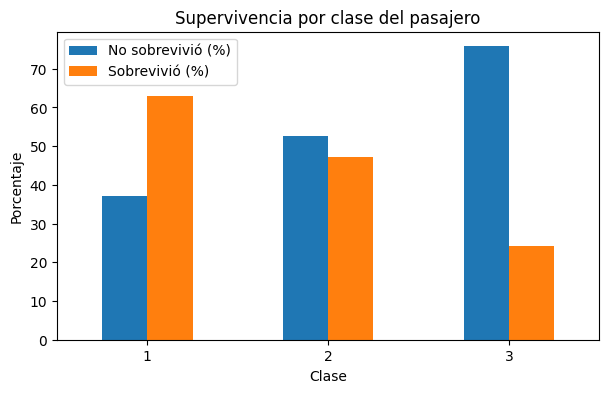

In [ ]:
tabla_clase.plot(kind="bar", figsize=(7,4))
plt.title("Supervivencia por clase del pasajero")
plt.xlabel("Clase")
plt.ylabel("Porcentaje")
plt.xticks(rotation=0)
plt.show()

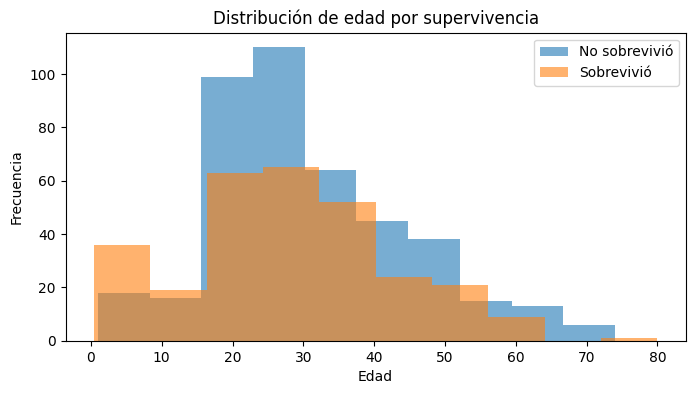

In [ ]:
# Edad por supervivencia
plt.figure(figsize=(8,4))
plt.hist(df[df["Survived"] == 0]["Age"].dropna(), alpha=0.6, label="No sobrevivió")
plt.hist(df[df["Survived"] == 1]["Age"].dropna(), alpha=0.6, label="Sobrevivió")
plt.title("Distribución de edad por supervivencia")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

# 8. Preparación de datos

No todas las columnas son útiles directamente para el modelo.

## Columnas que no usaremos

| Columna | Razón |
|---|---|
| PassengerId | Identificador, no aporta patrón general |
| Name | Texto complejo, requiere procesamiento adicional |
| Ticket | Código alfanumérico difícil de usar directamente |
| Cabin | Muchos faltantes |
| Survived | Es la variable objetivo |

## Variables que sí usaremos

- Pclass
- Sex
- Age
- SibSp
- Parch
- Fare
- Embarked

---

## Conversión de variables categóricas

Los árboles de `scikit-learn` requieren variables numéricas.

Convertiremos:

- `Sex`: male/female a 0/1.
- `Embarked`: variables dummy.

In [ ]:
# ============================================================
# 3. Preparación del dataset para modelado
# ============================================================

df_model = df[["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]].copy()

# Imputar edad con mediana
df_model["Age"] = df_model["Age"].fillna(df_model["Age"].median())

# Imputar puerto de embarque con moda
df_model["Embarked"] = df_model["Embarked"].fillna(df_model["Embarked"].mode()[0])

# Convertir Sex a variable numérica
df_model["Sex"] = df_model["Sex"].map({"male": 0, "female": 1})

# Convertir Embarked en variables dummy
df_model = pd.get_dummies(df_model, columns=["Embarked"], drop_first=True)

df_model.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


In [ ]:
# Verificación final
print("Dimensiones del dataset modelado:", df_model.shape)
print("\nValores faltantes después de limpieza:")
print(df_model.isna().sum())

Dimensiones del dataset modelado: (891, 9)

Valores faltantes después de limpieza:
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
dtype: int64


# 9. Separación entre X e y

Definimos:

- `X`: variables predictoras.
- `y`: variable objetivo.

La variable `Survived` no debe estar dentro de `X`, porque sería fuga de información.

In [ ]:
X = df_model.drop(columns=["Survived"])
y = df_model["Survived"]

print("X:", X.shape)
print("y:", y.shape)
print("Variables predictoras:")
print(list(X.columns))

X: (891, 8)
y: (891,)
Variables predictoras:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']


# 10. Train/Test split

Separaremos:

- 70% para entrenamiento.
- 30% para prueba.

Usamos `stratify=y` para conservar proporciones similares de sobrevivientes y no sobrevivientes en ambos conjuntos.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

print("\nDistribución train:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nDistribución test:")
print(y_test.value_counts(normalize=True).sort_index())

Train: (623, 8)
Test: (268, 8)

Distribución train:
Survived
0    0.616372
1    0.383628
Name: proportion, dtype: float64

Distribución test:
Survived
0    0.615672
1    0.384328
Name: proportion, dtype: float64


# 11. ¿Cómo aprende un árbol?

El árbol busca divisiones del tipo:

\[
x_j \leq c
\]

Donde:

- \(x_j\) es una variable.
- \(c\) es un punto de corte.

Ejemplo:

```text
Sex <= 0.5
Fare <= 26.25
Age <= 12.5
```

Cada división busca que los grupos resultantes sean más puros.

# 12. Impureza, Gini y Entropía

Un nodo es puro si contiene observaciones de una sola clase.

Ejemplo:

```text
Nodo A: 40 no sobrevivieron, 0 sobrevivieron → puro
Nodo B: 20 no sobrevivieron, 20 sobrevivieron → impuro
```

---

## Índice de Gini

\[
Gini = 1 - \sum_{i=1}^{k} p_i^2
\]

## Entropía

\[
Entropy = - \sum_{i=1}^{k} p_i \log_2(p_i)
\]

Ambas medidas buscan cuantificar qué tan mezcladas están las clases en un nodo.

In [ ]:
def gini(proporciones):
    return 1 - sum([p**2 for p in proporciones])

def entropia(proporciones):
    resultado = 0
    for p in proporciones:
        if p > 0:
            resultado -= p * np.log2(p)
    return resultado

ejemplos = {
    "Nodo puro [1.0, 0.0]": [1.0, 0.0],
    "Nodo 50/50 [0.5, 0.5]": [0.5, 0.5],
    "Nodo 80/20 [0.8, 0.2]": [0.8, 0.2],
    "Nodo 90/10 [0.9, 0.1]": [0.9, 0.1]
}

for nombre, props in ejemplos.items():
    print(nombre, "| Gini:", round(gini(props), 3), "| Entropía:", round(entropia(props), 3))

Nodo puro [1.0, 0.0] | Gini: 0.0 | Entropía: 0.0
Nodo 50/50 [0.5, 0.5] | Gini: 0.5 | Entropía: 1.0
Nodo 80/20 [0.8, 0.2] | Gini: 0.32 | Entropía: 0.722
Nodo 90/10 [0.9, 0.1] | Gini: 0.18 | Entropía: 0.469


# 13. Entrenamiento del árbol base

Entrenaremos un árbol con:

- `criterion="gini"`
- `max_depth=3`
- `random_state=42`

Limitamos la profundidad para que el árbol sea interpretable.

In [ ]:
arbol_base = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

arbol_base.fit(X_train, y_train)

print("Árbol base entrenado correctamente.")

Árbol base entrenado correctamente.


# 14. Evaluación del modelo

Evaluaremos:

- Accuracy
- Precision
- Recall
- F1-score
- Matriz de confusión

Recordemos:

\[
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
\]

\[
Precision = \frac{TP}{TP + FP}
\]

\[
Recall = \frac{TP}{TP + FN}
\]

\[
F1 = 2\frac{Precision \cdot Recall}{Precision + Recall}
\]

In [ ]:
y_pred = arbol_base.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1-score:", round(f1_score(y_test, y_pred), 4))

print("\nReporte completo:")
print(classification_report(y_test, y_pred, target_names=["No sobrevivió", "Sobrevivió"]))

Accuracy: 0.7948
Precision: 0.875
Recall: 0.5437
F1-score: 0.6707

Reporte completo:
               precision    recall  f1-score   support

No sobrevivió       0.77      0.95      0.85       165
   Sobrevivió       0.88      0.54      0.67       103

     accuracy                           0.79       268
    macro avg       0.82      0.75      0.76       268
 weighted avg       0.81      0.79      0.78       268



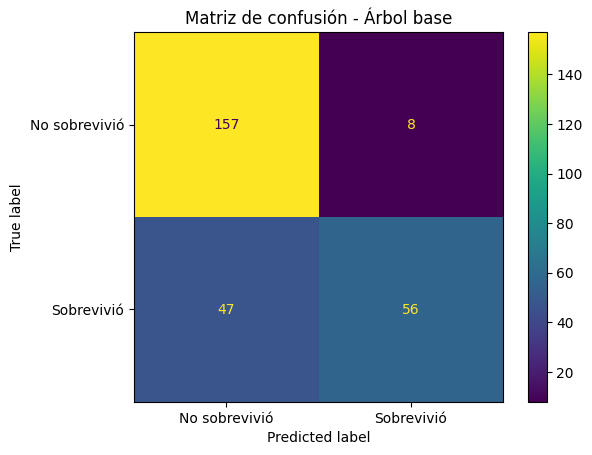

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No sobrevivió", "Sobrevivió"]
)

disp.plot()
plt.title("Matriz de confusión - Árbol base")
plt.show()

# 15. Interpretación de la matriz de confusión

En este problema:

- Clase 0: no sobrevivió.
- Clase 1: sobrevivió.

La matriz permite ver:

| Tipo de resultado | Interpretación |
|---|---|
| Verdadero negativo | Predijo no sobrevivió y realmente no sobrevivió |
| Verdadero positivo | Predijo sobrevivió y realmente sobrevivió |
| Falso positivo | Predijo sobrevivió pero no sobrevivió |
| Falso negativo | Predijo no sobrevivió pero sí sobrevivió |

---

## Pregunta crítica

¿Qué tipo de error parece más grave en este contexto histórico?

Falso negativo, dado que si alguien hubiese sobrevivido, estamoriamos reduciendo sus oportunidades de ser rescatada, por supuesto, en el caso hipótetico, que asi pudieramos

No es un problema médico actual, pero sirve para discutir cómo el costo del error depende del contexto.

# 16. Visualización del árbol

Ahora visualizaremos el árbol.

Cada nodo muestra:

- Condición de división.
- Índice de Gini.
- Número de muestras.
- Distribución de clases.
- Clase predicha.

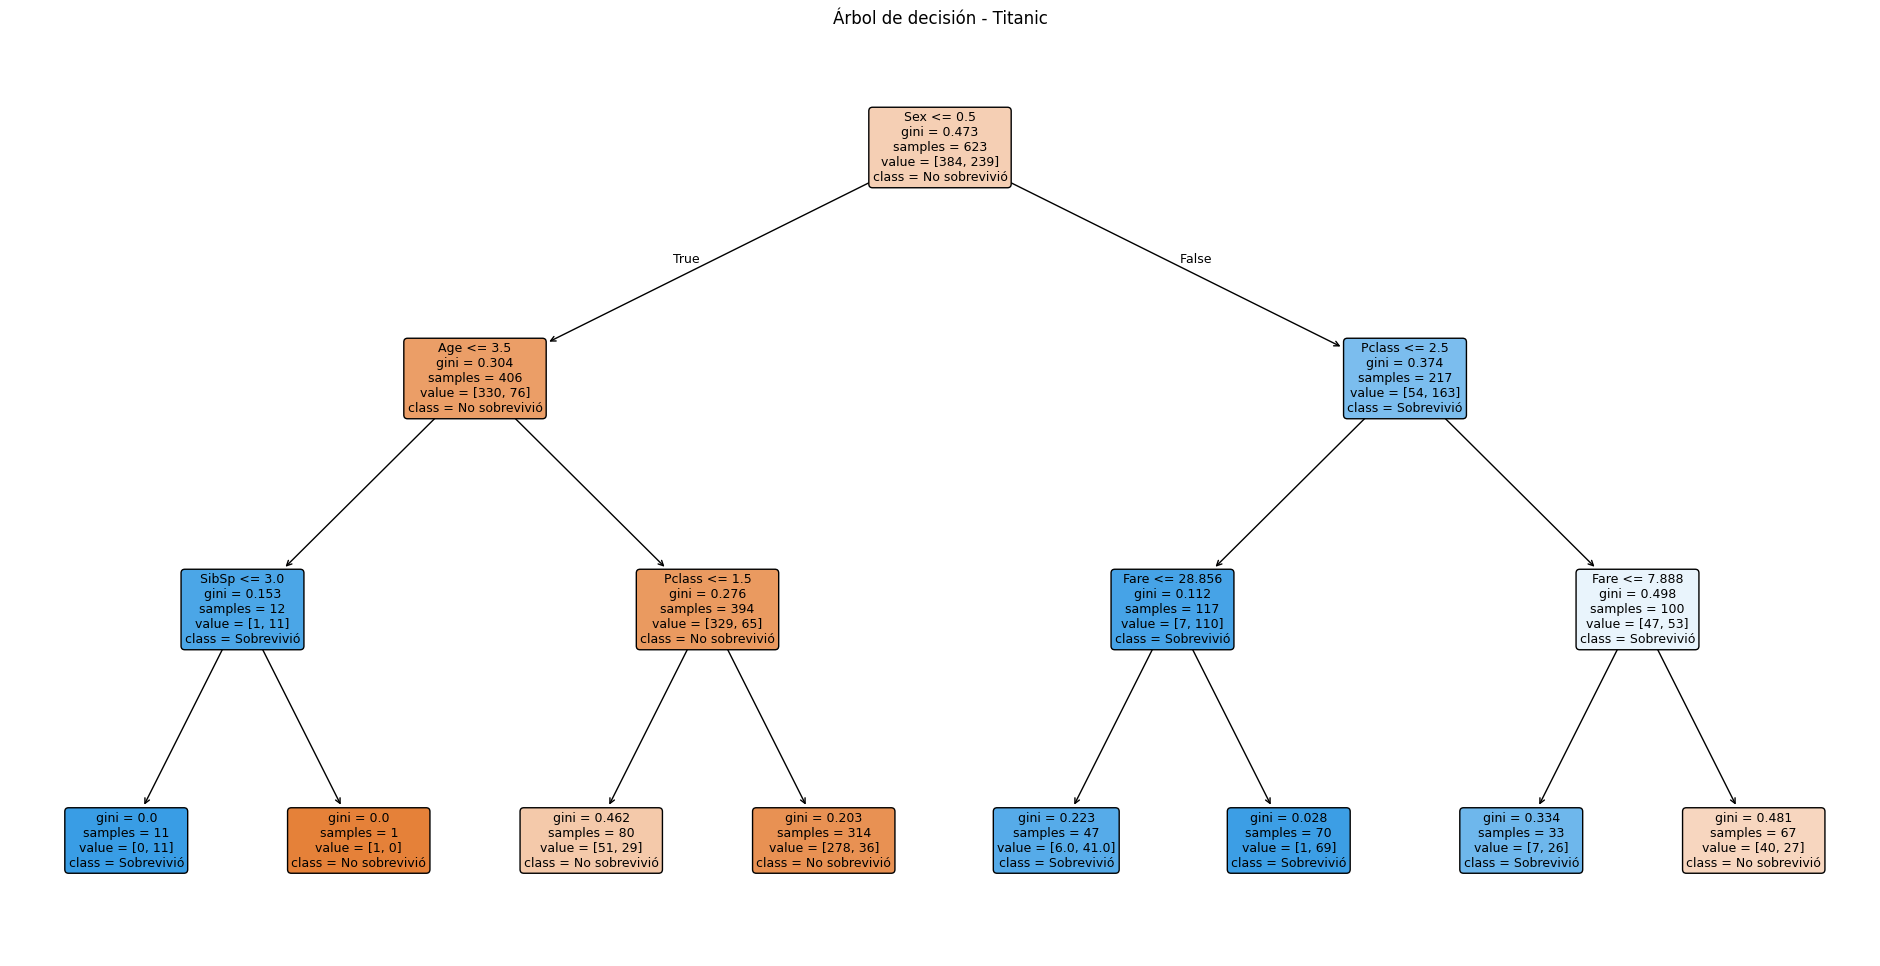

In [ ]:
plt.figure(figsize=(24, 12))

plot_tree(
    arbol_base,
    feature_names=X.columns,
    class_names=["No sobrevivió", "Sobrevivió"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Árbol de decisión - Titanic")
plt.show()

# 17. Reglas del árbol en texto

Exportar el árbol como texto permite leer las reglas más claramente.

Esto es útil para transformar el modelo en explicación.

In [ ]:
reglas = export_text(arbol_base, feature_names=list(X.columns))
print(reglas)

|--- Sex <= 0.50
|   |--- Age <= 3.50
|   |   |--- SibSp <= 3.00
|   |   |   |--- class: 1
|   |   |--- SibSp >  3.00
|   |   |   |--- class: 0
|   |--- Age >  3.50
|   |   |--- Pclass <= 1.50
|   |   |   |--- class: 0
|   |   |--- Pclass >  1.50
|   |   |   |--- class: 0
|--- Sex >  0.50
|   |--- Pclass <= 2.50
|   |   |--- Fare <= 28.86
|   |   |   |--- class: 1
|   |   |--- Fare >  28.86
|   |   |   |--- class: 1
|   |--- Pclass >  2.50
|   |   |--- Fare <= 7.89
|   |   |   |--- class: 1
|   |   |--- Fare >  7.89
|   |   |   |--- class: 0



## Actividad rápida

Seleccione una regla y escríbala en lenguaje natural.

Ejemplo:

```text
Si Sex <= 0.5 y Pclass > 1.5, entonces el modelo predice no sobrevivió.
```

Luego responda:

1. ¿Qué significa `Sex <= 0.5`?
   Aquellos de sexo masculino, sex<=0.5 para masculino -> sex>0.5 para femenino
2. ¿Qué significa `Pclass`?
   Pasajeros que sean de segunda o tercera clase de la embarcación
3. ¿La regla parece tener sentido histórico?
   Si, dado que las mujeres fueron las primeras pasajeras en desembarcar en los botes de emergencia.

# 18. Importancia de variables

Los árboles permiten calcular importancia de variables.

Esto indica qué variables ayudaron más a reducir impureza.

No significa causalidad, sino utilidad predictiva dentro del modelo.

In [ ]:
importancias = pd.DataFrame({
    "variable": X.columns,
    "importancia": arbol_base.feature_importances_
}).sort_values("importancia", ascending=False)

importancias

,variable,importancia
1,Sex,0.650916
0,Pclass,0.187957
2,Age,0.095227
5,Fare,0.052633
3,SibSp,0.013266
4,Parch,0.000000
6,Embarked_Q,0.000000
7,Embarked_S,0.000000


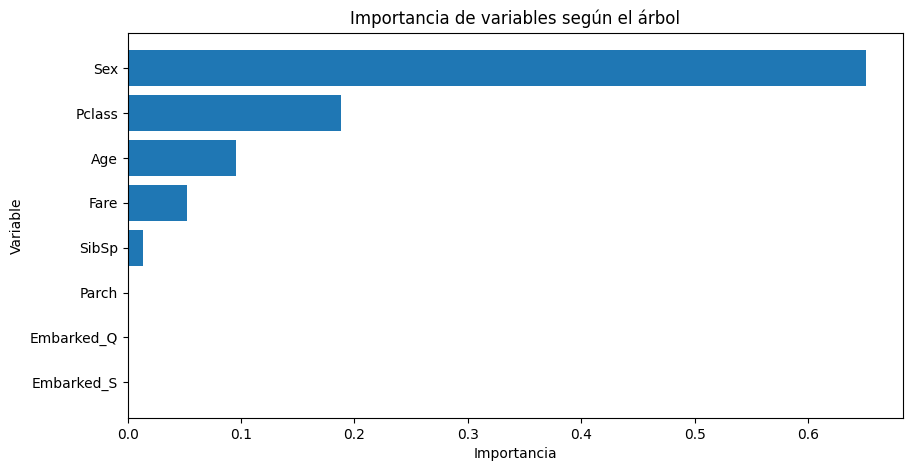

In [ ]:
plt.figure(figsize=(10, 5))
plt.barh(importancias["variable"], importancias["importancia"])
plt.gca().invert_yaxis()
plt.title("Importancia de variables según el árbol")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

# 19. Overfitting en árboles

Los árboles pueden sobreajustar.

Un árbol muy profundo puede memorizar detalles del entrenamiento:

```text
Si Sex = female
y Age = 28
y Fare = 13.5
y Parch = 1
entonces...
```

Eso puede funcionar muy bien en train, pero mal en test.

---

## Señales de overfitting

| Señal | Interpretación |
|---|---|
| Accuracy train muy alta | El modelo aprendió mucho del entrenamiento |
| Accuracy test menor | Mala generalización |
| Árbol muy profundo | Reglas demasiado específicas |
| Hojas con pocas observaciones | Memorización posible |

# 20. Comparación de profundidades

Entrenaremos árboles con diferentes valores de `max_depth`.

Compararemos:

- Accuracy train
- Accuracy test
- F1 test

Esto ayuda a decidir qué profundidad es razonable.

In [ ]:
profundidades = [1, 2, 3, 4, 5, 6, 8, 10, None]
resultados = []

for p in profundidades:
    modelo = DecisionTreeClassifier(
        criterion="gini",
        max_depth=p,
        random_state=42
    )

    modelo.fit(X_train, y_train)

    pred_train = modelo.predict(X_train)
    pred_test = modelo.predict(X_test)

    resultados.append({
        "max_depth": str(p),
        "accuracy_train": accuracy_score(y_train, pred_train),
        "accuracy_test": accuracy_score(y_test, pred_test),
        "f1_test": f1_score(y_test, pred_test)
    })

df_resultados = pd.DataFrame(resultados)
df_resultados

,max_depth,accuracy_train,accuracy_test,f1_test
0,1,0.791332,0.776119,0.700000
1,2,0.807384,0.768657,0.699029
2,3,0.829856,0.794776,0.670659
3,4,0.845907,0.794776,0.674556
4,5,0.863563,0.787313,0.681564
5,6,0.879615,0.798507,0.696629
6,8,0.910112,0.779851,0.677596
7,10,0.939005,0.764925,0.670157
8,None,0.979133,0.764925,0.680203


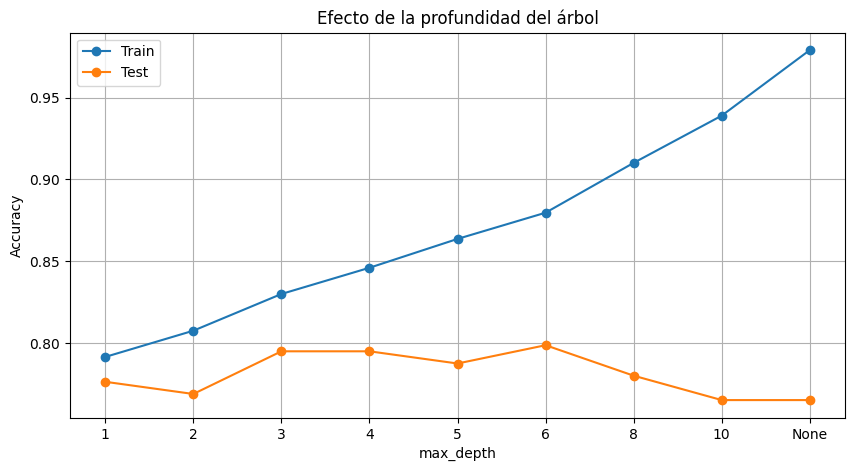

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(df_resultados["max_depth"], df_resultados["accuracy_train"], marker="o", label="Train")
plt.plot(df_resultados["max_depth"], df_resultados["accuracy_test"], marker="o", label="Test")

plt.title("Efecto de la profundidad del árbol")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## Interpretación esperada

Preguntas para clase:

1. ¿El accuracy de train aumenta con la profundidad?
   Si, aumenta con la profundidad del arbol, casi de forma lineal
2. ¿El accuracy de test aumenta siempre?
   No, la precisión alcanza su punto optimo en 6, y luego, reduciendose a minimos
3. ¿En qué punto aparece posible sobreajuste?
   El sobreajuste empieza después del nivel de profundidad 6, cuando la precisión de entrenamiento sigue aumentando, pero la de prueba empieza a disminuir
4. ¿Qué profundidad parece más razonable?
   La profundidad más razonable es de 4 a 6, donde tenemos un mejor balance entre desempeño en entrenamiento y prueba
5. ¿Cuál árbol sería más fácil de explicar?
   Un arbol de menor profundidad permite mayor interpretabilidad, dado que tendriamos menos reglas de condición para su evaluación

# 21. Comparación Gini vs Entropía

Ahora comparamos dos árboles:

- Uno con `criterion="gini"`.
- Uno con `criterion="entropy"`.

Ambos con la misma profundidad.

In [ ]:
comparacion = []

for criterio in ["gini", "entropy"]:
    modelo = DecisionTreeClassifier(
        criterion=criterio,
        max_depth=3,
        random_state=42
    )

    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)

    comparacion.append({
        "criterio": criterio,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred)
    })

pd.DataFrame(comparacion)

,criterio,accuracy,precision,recall,f1
0,gini,0.794776,0.875,0.543689,0.670659
1,entropy,0.794776,0.875,0.543689,0.670659


# 22. Regularización del árbol

Además de `max_depth`, se pueden usar otros parámetros:

| Parámetro | Función |
|---|---|
| `max_depth` | Limita profundidad |
| `min_samples_split` | Mínimo de muestras para dividir un nodo |
| `min_samples_leaf` | Mínimo de muestras en una hoja |
| `criterion` | Criterio de división |
| `class_weight` | Peso de clases |

Estos parámetros controlan la complejidad del modelo.

In [ ]:
arbol_regularizado = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    min_samples_leaf=10,
    random_state=42
)

arbol_regularizado.fit(X_train, y_train)
pred_reg = arbol_regularizado.predict(X_test)

print(classification_report(y_test, pred_reg, target_names=["No sobrevivió", "Sobrevivió"]))

               precision    recall  f1-score   support

No sobrevivió       0.78      0.92      0.84       165
   Sobrevivió       0.82      0.57      0.67       103

     accuracy                           0.79       268
    macro avg       0.80      0.75      0.76       268
 weighted avg       0.79      0.79      0.78       268



# 23. Lectura crítica

Un árbol de decisión no debe evaluarse solo por accuracy.

Una evaluación profesional considera:

1. Métricas.
2. Matriz de confusión.
3. Interpretación de errores.
4. Interpretabilidad.
5. Posible sobreajuste.
6. Calidad del dataset.
7. Variables excluidas.
8. Sesgos históricos del dato.

---

## Ventajas

- Fácil de explicar.
- No requiere escalado.
- Produce reglas.
- Permite visualizar la decisión.
- Es útil como modelo base.

## Desventajas

- Puede sobreajustar.
- Puede ser inestable.
- Depende de la calidad de los datos.
- Puede reflejar sesgos del dataset.
- Un solo árbol no siempre es el mejor predictor.

# 🧪 24. Taller final de clase

## Objetivo

Entrenar, evaluar e interpretar un árbol de decisión usando el dataset Titanic.

## Forma de trabajo

Grupos de 2 o 3 estudiantes.

## Entregable

Un notebook o documento con:

1. Análisis inicial del dataset.
2. Limpieza y preparación.
3. Entrenamiento de árbol.
4. Métricas.
5. Matriz de confusión.
6. Visualización del árbol.
7. Interpretación de reglas.
8. Conclusión profesional.

No se evalúa solo que el código funcione. Se evalúa la interpretación.

## Parte A — Comprensión del problema

Responda:

1. ¿Cuál es la pregunta de minería de datos?
2. ¿Cuál es la variable objetivo?
3. ¿Qué representa la clase 0?
4. ¿Qué representa la clase 1?
5. ¿Qué tipo de problema es?
6. ¿Qué variables podrían influir en la supervivencia?

### Respuestas — Parte A

1. **¿Cuál es la pregunta de minería de datos?**  
   Determinar si es posible predecir la supervivencia de un pasajero del Titanic a partir de sus características registradas.

2. **¿Cuál es la variable objetivo?**  
   La variable objetivo es **`Survived`**.

3. **¿Qué representa la clase 0?**  
   La clase **0** representa: **no sobrevivió**.

4. **¿Qué representa la clase 1?**  
   La clase **1** representa: **sobrevivió**.

5. **¿Qué tipo de problema es?**  
   Es un problema de **clasificación supervisada binaria**.

6. **¿Qué variables podrían influir en la supervivencia?**  
   Variables como **`Sex`**, **`Pclass`**, **`Age`**, **`Fare`**, **`SibSp`**, **`Parch`** y **`Embarked`** pueden influir en la probabilidad de supervivencia.

### Conclusión breve

El problema está bien definido como una tarea de clasificación binaria y cuenta con variables demográficas, económicas y de contexto de viaje que permiten entrenar un modelo predictivo e interpretar factores asociados a la supervivencia.

## Parte B — Exploración

Realice:

1. Número de filas y columnas.
2. Valores faltantes.
3. Distribución de `Survived`.
4. Supervivencia por sexo.
5. Supervivencia por clase.
6. Una conclusión preliminar.

In [ ]:
# Parte B - Espacio de trabajo

print("Dimensiones:", df.shape)
print("\nValores faltantes:")
print(df.isna().sum())

print("\nDistribución de Survived:")
print(df["Survived"].value_counts(normalize=True))

Dimensiones: (891, 12)

Valores faltantes:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Distribución de Survived:
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


### Interpretación — Dimensiones, faltantes y distribución de `Survived`

A partir de la salida de la celda anterior:

- El dataset tiene **891 filas** y **12 columnas**.
- Los faltantes principales son:
  - **`Cabin`: 687** valores faltantes.
  - **`Age`: 177** valores faltantes.
  - **`Embarked`: 2** valores faltantes.
- La variable objetivo `Survived` está desbalanceada de forma moderada:
  - **No sobrevivió (0): 549 pasajeros (61.62%)**.
  - **Sobrevivió (1): 342 pasajeros (38.38%)**.

Esto indica que, antes de modelar, se debe tratar faltantes y evaluar métricas más allá de accuracy.

In [ ]:
# Parte B - Supervivencia por sexo

tabla_sexo_b = pd.crosstab(df["Sex"], df["Survived"], normalize="index") * 100
tabla_sexo_b.columns = ["No sobrevivió (%)", "Sobrevivió (%)"]

tabla_sexo_b.round(2)

,No sobrevivió (%),Sobrevivió (%)
Sex,,
female,25.80,74.20
male,81.11,18.89


### Interpretación — Supervivencia por sexo

Según los resultados:

- En **hombres** la tasa de no supervivencia es claramente mayoritaria (alrededor de 81%).
- En **mujeres** la tasa de supervivencia es claramente mayoritaria (alrededor de 74%).

Esto sugiere que la variable `Sex` tiene alto poder explicativo para el objetivo `Survived`.

In [ ]:
# Parte B - Supervivencia por clase

tabla_clase_b = pd.crosstab(df["Pclass"], df["Survived"], normalize="index") * 100
tabla_clase_b.columns = ["No sobrevivió (%)", "Sobrevivió (%)"]

tabla_clase_b.round(2)

,No sobrevivió (%),Sobrevivió (%)
Pclass,,
1,37.04,62.96
2,52.72,47.28
3,75.76,24.24


### Interpretación — Supervivencia por clase

Los porcentajes por clase muestran un patrón claro:

- **Primera clase (1):** mayor supervivencia (aprox. 63%).
- **Segunda clase (2):** comportamiento intermedio (aprox. 47% supervivencia).
- **Tercera clase (3):** menor supervivencia (aprox. 24%).

La variable `Pclass` también parece muy relevante para explicar la supervivencia.

### Conclusión preliminar — Parte B

La exploración inicial muestra que el dataset tiene tamaño manejable para clase, pero con faltantes importantes en `Cabin` y `Age`, por lo que será necesario tratamiento de datos antes del modelado. Además, la supervivencia no está completamente balanceada y presenta patrones marcados por **sexo** y **clase del pasajero**. En consecuencia, hay evidencia suficiente para esperar que un árbol de decisión pueda encontrar reglas interpretables y útiles para predecir `Survived`.

## Parte C — Entrenamiento del modelo base

Entrene un árbol con:

- `criterion="gini"`
- `max_depth=3`
- `random_state=42`

Reporte:

1. Accuracy.

2. Precision.
3. Recall.
4. F1-score.
5. Matriz de confusión.

Explique cada resultado.

               precision    recall  f1-score   support

No sobrevivió       0.77      0.95      0.85       165
   Sobrevivió       0.88      0.54      0.67       103

     accuracy                           0.79       268
    macro avg       0.82      0.75      0.76       268
 weighted avg       0.81      0.79      0.78       268



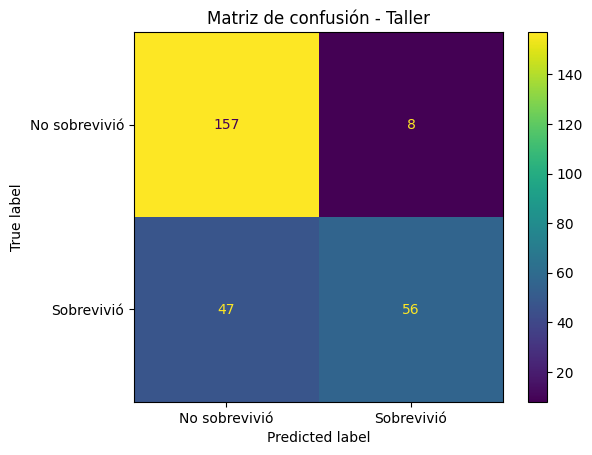

In [ ]:
# Parte C - Modelo base

modelo_taller = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

modelo_taller.fit(X_train, y_train)
pred_taller = modelo_taller.predict(X_test)

print(classification_report(y_test, pred_taller, target_names=["No sobrevivió", "Sobrevivió"]))

cm_taller = confusion_matrix(y_test, pred_taller)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_taller, display_labels=["No sobrevivió", "Sobrevivió"])
disp.plot()
plt.title("Matriz de confusión - Taller")
plt.show()

## Parte C — Entrenamiento del modelo base

Se entrenó un árbol de decisión con los siguientes parámetros:

- `criterion = "gini"`
- `max_depth = 3`
- `random_state = 42`

---

### 1. Accuracy

El modelo obtuvo un accuracy de **0.79**, lo que indica que clasifica correctamente el **79% de los casos**.  
Esta métrica proporciona una visión general del desempeño, pero no distingue entre clases.

---

### 2. Precision

- **No sobrevivió:** 0.77  
- **Sobrevivió:** 0.88  

La precisión mide qué tan confiables son las predicciones positivas.

El modelo presenta una mayor precisión en la clase *“Sobrevivió”*, lo que indica que cuando predice que alguien sobrevivió, generalmente es correcto.

---

### 3. Recall

- **No sobrevivió:** 0.95  
- **Sobrevivió:** 0.54  

El recall mide la capacidad del modelo para identificar correctamente los casos reales.

El modelo identifica muy bien a los pasajeros que no sobrevivieron, pero tiene dificultades para detectar a los sobrevivientes, ya que solo reconoce el 54% de ellos.

---

### 4. F1-score

- **No sobrevivió:** 0.85  
- **Sobrevivió:** 0.67  

El F1-score es el equilibrio entre precisión y recall.

Se observa un mejor desempeño en la clase *“No sobrevivió”*, mientras que la clase *“Sobrevivió”* se ve afectada por el bajo recall.

---

### 5. Matriz de confusión

|                  | Pred: No sobrevivió | Pred: Sobrevivió |
|------------------|--------------------|------------------|
| **Real No sobrevivió** | 157                | 8                |
| **Real Sobrevivió**    | 47                 | 56               |

---

### Interpretación de la matriz

- **Verdaderos negativos (157):** El modelo clasifica correctamente a la mayoría de los que no sobrevivieron.  
- **Falsos positivos (8):** Pocos casos donde se predice supervivencia incorrectamente.  
- **Falsos negativos (47):** Número considerable de sobrevivientes mal clasificados como fallecidos.  
- **Verdaderos positivos (56):** El modelo identifica algunos sobrevivientes, pero no la mayoría.

---

### Conclusión

El modelo presenta un buen desempeño general, pero está claramente sesgado hacia la clase *“No sobrevivió”*.  
Esto se evidencia en el alto recall de esta clase (0.95) y el bajo recall de la clase *“Sobrevivió”* (0.54).

En consecuencia, el modelo tiene dificultades para detectar correctamente a los sobrevivientes, lo que sugiere un problema de desbalance o limitación en la complejidad del árbol, dado que solo tenemos profundidad de 3, otorgando mayor cantidad de sobrevivientes y permitiendo mayores falsos negativos, pasajeros declarados no sobrevivientes que si sobrevivieron, lo cual es preocupante para tomar como predicción


## Parte D — Comparación de profundidades

Entrene árboles con:

- `max_depth=1`
- `max_depth=2`
- `max_depth=3`
- `max_depth=5`
- `max_depth=8`
- `max_depth=None`

Construya una tabla con:

- Accuracy train.
- Accuracy test.
- F1 test.

Responda:

1. ¿Qué profundidad parece más adecuada?
2. ¿Hay evidencia de overfitting?
3. ¿Cuál modelo es más interpretable?
4. ¿Cuál elegiría para presentar?

In [ ]:
# Parte D - Comparación

profundidades_taller = [1, 2, 3, 5, 8, None]
resultados_taller = []

for p in profundidades_taller:
    modelo = DecisionTreeClassifier(
        criterion="gini",
        max_depth=p,
        random_state=42
    )

    modelo.fit(X_train, y_train)

    pred_train = modelo.predict(X_train)
    pred_test = modelo.predict(X_test)

    resultados_taller.append({
        "max_depth": str(p),
        "accuracy_train": accuracy_score(y_train, pred_train),
        "accuracy_test": accuracy_score(y_test, pred_test),
        "f1_test": f1_score(y_test, pred_test)
    })

pd.DataFrame(resultados_taller)

,max_depth,accuracy_train,accuracy_test,f1_test
0,1,0.791332,0.776119,0.700000
1,2,0.807384,0.768657,0.699029
2,3,0.829856,0.794776,0.670659
3,5,0.863563,0.787313,0.681564
4,8,0.910112,0.779851,0.677596
5,None,0.979133,0.764925,0.680203


## Análisis de profundidad del árbol

### 1. ¿Qué profundidad parece más adecuada?

La profundidad más adecuada es **3**, ya que presenta el mejor desempeño en el conjunto de prueba (`accuracy_test ≈ 0.795`).  

Aunque profundidades mayores como 5 u 8 aumentan la precisión en entrenamiento, no mejoran el rendimiento en test, lo que indica pérdida de generalización.

---

### 2. ¿Hay evidencia de overfitting?

Sí. A partir de profundidades mayores a 3 se observa que:

- El `accuracy_train` sigue aumentando (hasta ≈ 0.97)
- El `accuracy_test` disminuye (≈ 0.76–0.78)

Esto indica que el modelo empieza a memorizar los datos de entrenamiento en lugar de generalizar.

---

### 3. ¿Cuál modelo es más interpretable?

El modelo más interpretable es el de **profundidad 1**, ya que tiene menos reglas y decisiones más simples.

Sin embargo, este modelo presenta menor rendimiento, por lo que existe un compromiso entre interpretabilidad y desempeño.

---

### 4. ¿Cuál elegiría para presentar?

Elegiría el modelo con **profundidad 3**, ya que:

- Tiene el mejor desempeño en datos de prueba
- Evita el sobreajuste
- Mantiene un nivel razonable de interpretabilidad

En conclusión, representa el mejor equilibrio entre simplicidad y capacidad predictiva.

## Parte E — Interpretación de reglas

Visualice el árbol y responda:

1. ¿Cuál es la primera variable usada para dividir?
2. ¿Qué significa esa variable?
3. Escriba una regla del árbol en lenguaje natural.
4. ¿La regla parece coherente?
5. ¿Qué sesgos históricos podrían existir en este dataset?

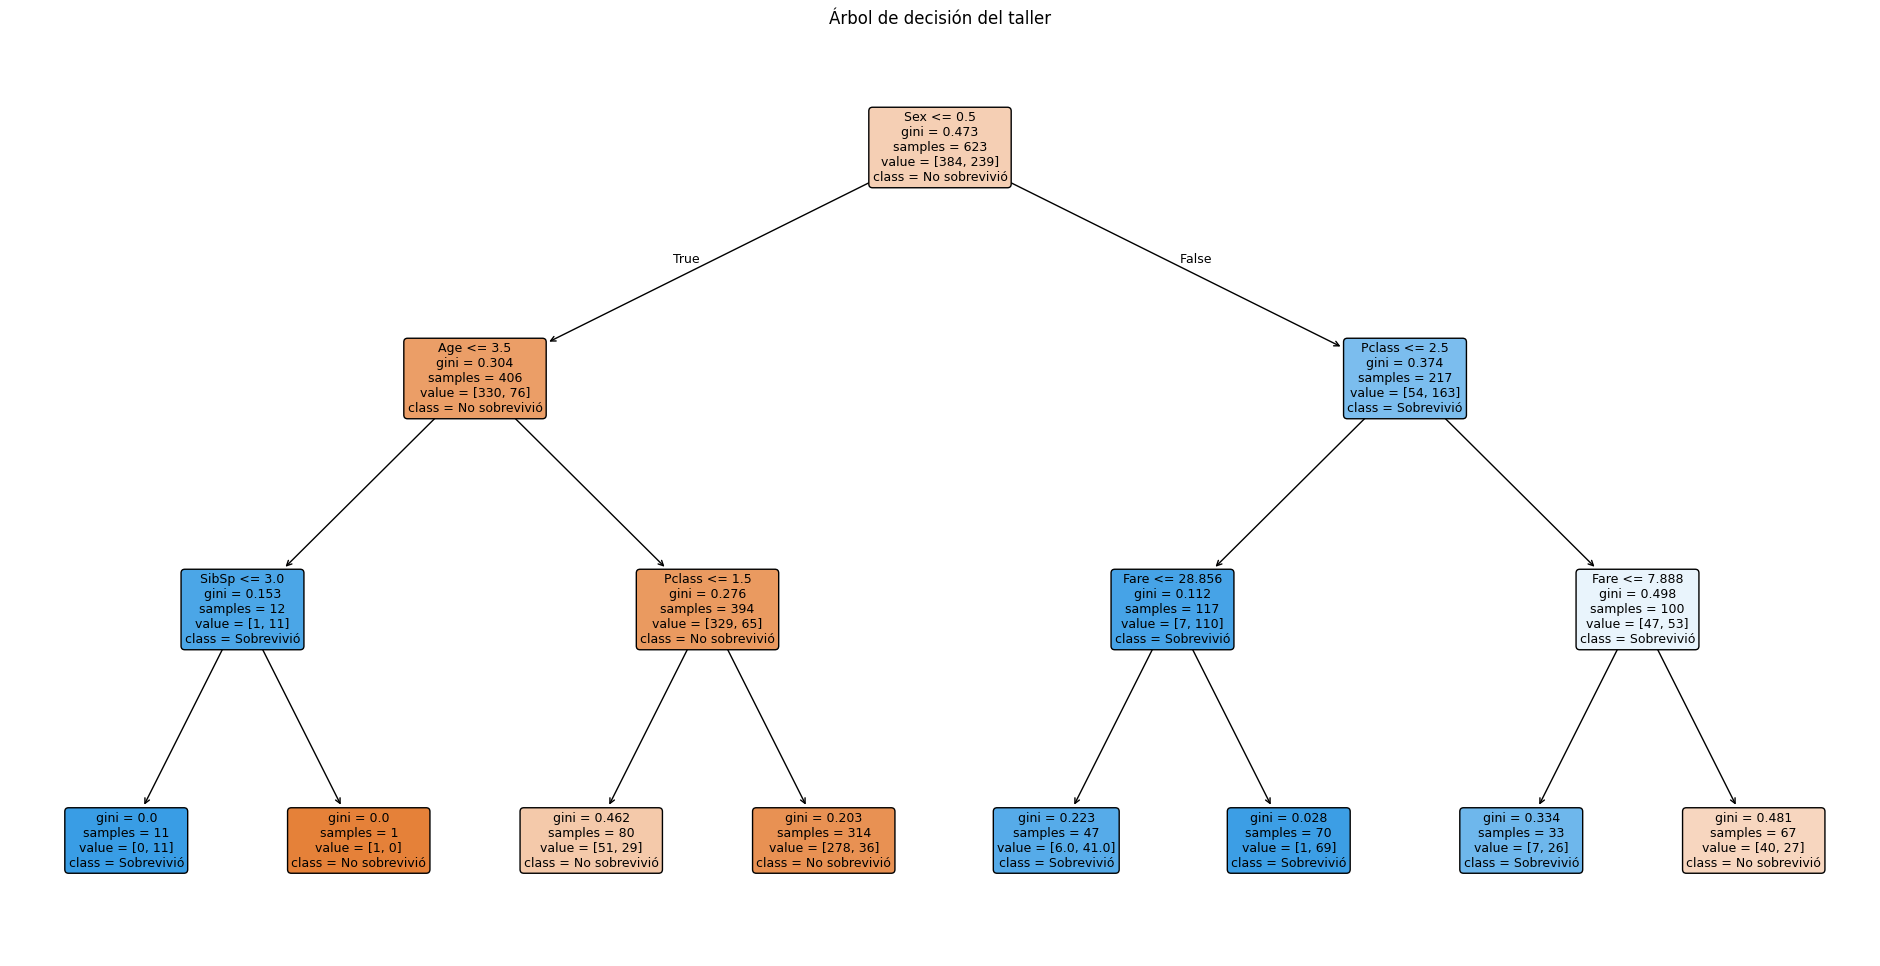

|--- Sex <= 0.50
|   |--- Age <= 3.50
|   |   |--- SibSp <= 3.00
|   |   |   |--- class: 1
|   |   |--- SibSp >  3.00
|   |   |   |--- class: 0
|   |--- Age >  3.50
|   |   |--- Pclass <= 1.50
|   |   |   |--- class: 0
|   |   |--- Pclass >  1.50
|   |   |   |--- class: 0
|--- Sex >  0.50
|   |--- Pclass <= 2.50
|   |   |--- Fare <= 28.86
|   |   |   |--- class: 1
|   |   |--- Fare >  28.86
|   |   |   |--- class: 1
|   |--- Pclass >  2.50
|   |   |--- Fare <= 7.89
|   |   |   |--- class: 1
|   |   |--- Fare >  7.89
|   |   |   |--- class: 0



In [ ]:
# Parte E - Visualización

plt.figure(figsize=(24, 12))

plot_tree(
    modelo_taller,
    feature_names=X.columns,
    class_names=["No sobrevivió", "Sobrevivió"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Árbol de decisión del taller")
plt.show()

print(export_text(modelo_taller, feature_names=list(X.columns)))

## Análisis del árbol de decisión

1. ¿Cuál es la primera variable usada para dividir?

La primera variable utilizada es **Sex**, ya que es la que genera mayor reducción de impureza (criterio Gini), siendo la más relevante para separar las clases.

---

2. ¿Qué significa esa variable?

Es una variable categórica que indica el sexo del pasajero (hombre o mujer).

---

3. Escriba una regla del árbol en lenguaje natural.

Si el pasajero es mujer, tiene mayor probabilidad de sobrevivir.
Si es hombre, entonces se consideran otras variables como la edad, el número de familiares a bordo (SibSp) y la clase (Pclass) para determinar su probabilidad de supervivencia.

---

4. ¿La regla parece coherente?

Sí, la regla es coherente, ya que refleja patrones históricos observados en el Titanic, donde el sexo, la edad y la clase social influyeron en las probabilidades de supervivencia.

---

5. ¿Qué sesgos históricos podrían existir en este dataset?

- Sesgo de género: prioridad a mujeres y niños.
- Sesgo de clase social: mayor supervivencia en clases altas.
- Sesgo económico: acceso desigual a recursos.
- Sesgo estructural: ubicación dentro del barco.

Estos factores muestran que la supervivencia estuvo influenciada por condiciones sociales y estructurales.

## Parte F — Conclusión profesional

Redacte una conclusión de mínimo 10 líneas respondiendo:

1. ¿El árbol de decisión es adecuado para este problema?
2. ¿Qué métrica considera más importante y por qué?
3. ¿Qué variables parecen más relevantes?
4. ¿Qué limitaciones tiene el modelo?
5. ¿Qué haría antes de usarlo en un caso real?
6. ¿Qué otro algoritmo compararía después?

La conclusión debe sonar como un informe técnico:
### RESPUESTA

El modelo de árbol de decisión implementado resulta ser una herramienta adecuada para este problema, principalmente por su alta interpretabilidad, lo cual es clave en escenarios donde entender el “por qué” de una predicción es tan importante como el resultado en sí. A partir del análisis realizado, se puede decir que el F1-score es la métrica más relevante en este caso, ya que logra un buen equilibrio entre precisión y recall, permitiendo evaluar mejor el desempeño del modelo en ambas clases y evitando el sesgo que el accuracy podría ocultar debido al desbalance moderado del dataset.

En cuanto a las variables, se observa que las más influyentes en la predicción son el sexo, la clase social y la edad, lo cual tiene bastante sentido y es coherente con lo que históricamente se conoce sobre la supervivencia en el Titanic.

Sin embargo, el modelo también presenta algunas limitaciones propias de su estructura, especialmente su tendencia a favorecer la clase mayoritaria (no sobrevivientes), lo que se refleja en una mayor cantidad de falsos negativos. Por esta razón, antes de pensar en usar este modelo en un entorno más real, sería importante aplicar técnicas más avanzadas, como el balanceo de clases y validación cruzada, para mejorar la estabilidad de los resultados.

Finalmente, como posible mejora, sería interesante comparar este modelo con métodos de ensamblaje como Random Forest o Gradient Boosting, ya que estos suelen tener una mejor capacidad de generalización y pueden capturar relaciones más complejas que un árbol de decisión individual.

# 25. Rúbrica sugerida

| Criterio | Puntaje |
|---|---:|
| Comprensión del problema | 0.6 |
| Exploración inicial | 0.7 |
| Preparación de datos | 0.7 |
| Entrenamiento del árbol | 0.8 |
| Evaluación con métricas | 0.9 |
| Comparación de profundidades | 0.8 |
| Interpretación de reglas | 0.3 |
| Conclusión profesional | 0.2 |
| **Total** | **5.0** |

---

# Cierre de clase

Los árboles de decisión permiten conectar:

1. Predicción.
2. Interpretabilidad.
3. Evaluación.
4. Reglas de decisión.
5. Control de sobreajuste.

La siguiente clase recomendada es:

## KNN y comparación de clasificadores

porque permite contrastar un modelo basado en reglas con un modelo basado en distancia.